In [1]:
import sys
from pathlib import Path

sys.path.insert(0, '../../')
import numpy as np
from matplotlib import pyplot as plt

import lsstypes as types
from clustering_statistics import tools, box_tools

plot_dir = Path('validation_fiber_assignment')
plot_dir.mkdir(exist_ok=True)
ext = 'pdf'

### Plot of angular upweights

/global/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics/full_shape/fiber_assignment_systematics/abacus-hf-dr2-v2-altmtl/mock0/particle2_angular_upweights_LRG_NGC_weight-default-FKP.h5


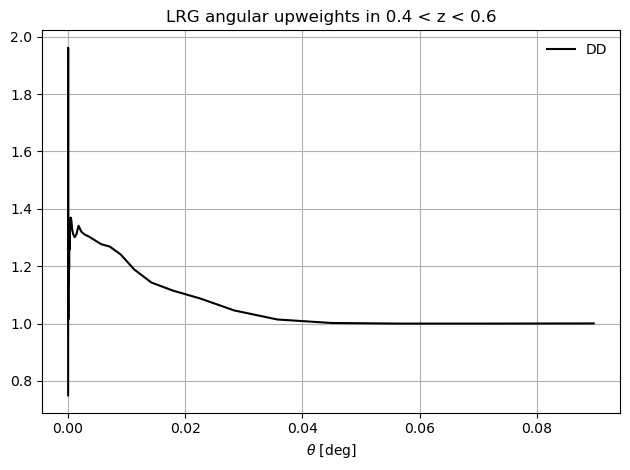

/global/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics/full_shape/fiber_assignment_systematics/abacus-hf-dr2-v2-altmtl/mock0/particle3_angular_upweights_LRG_NGC_weight-default-FKP.h5


/tmp/ipykernel_919314/1576085587.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False)


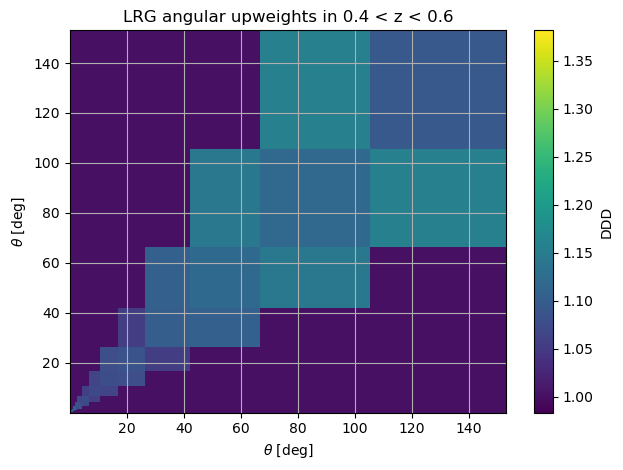

/global/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics/full_shape/fiber_assignment_systematics/abacus-hf-dr2-v2-altmtl/mock0/particle2_angular_upweights_LRG_NGC_weight-default-FKP.h5


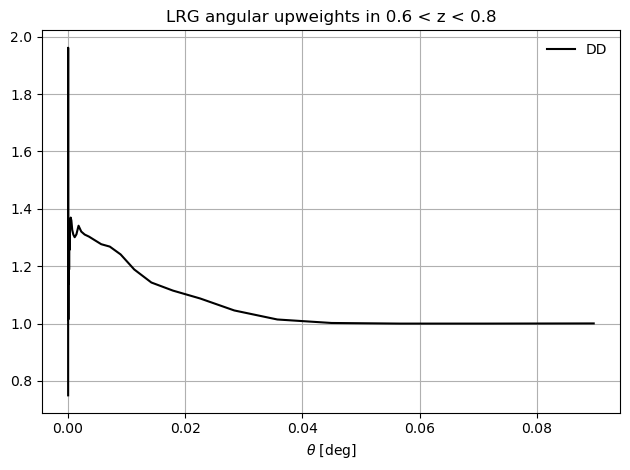

/global/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics/full_shape/fiber_assignment_systematics/abacus-hf-dr2-v2-altmtl/mock0/particle3_angular_upweights_LRG_NGC_weight-default-FKP.h5


/tmp/ipykernel_919314/1576085587.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False)


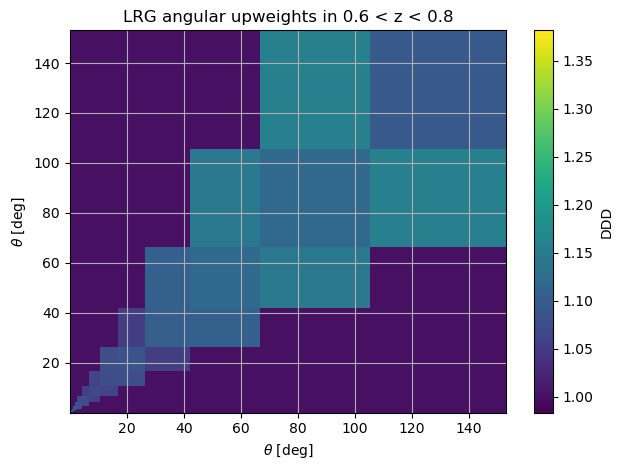

/global/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics/full_shape/fiber_assignment_systematics/abacus-hf-dr2-v2-altmtl/mock0/particle2_angular_upweights_LRG_NGC_weight-default-FKP.h5


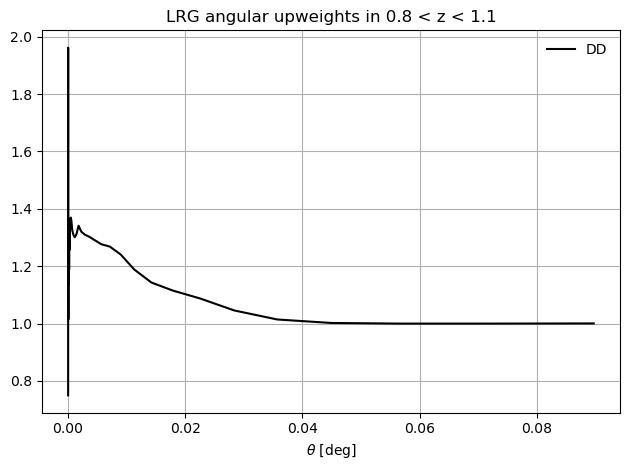

/global/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics/full_shape/fiber_assignment_systematics/abacus-hf-dr2-v2-altmtl/mock0/particle3_angular_upweights_LRG_NGC_weight-default-FKP.h5


/tmp/ipykernel_919314/1576085587.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False)


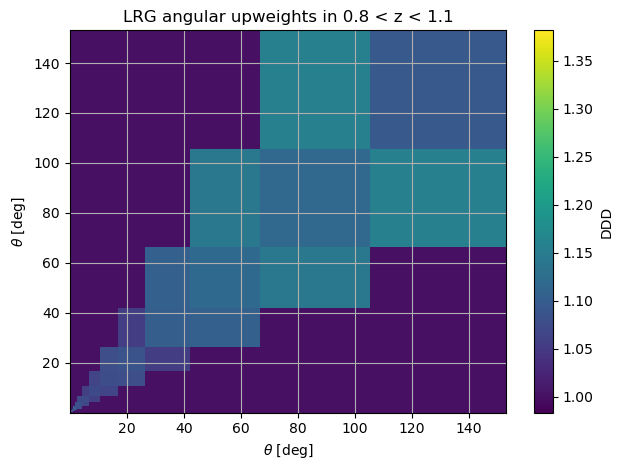

/global/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics/full_shape/fiber_assignment_systematics/abacus-hf-dr2-v2-altmtl/mock0/particle2_angular_upweights_ELG_LOPnotqso_NGC_weight-default-FKP.h5


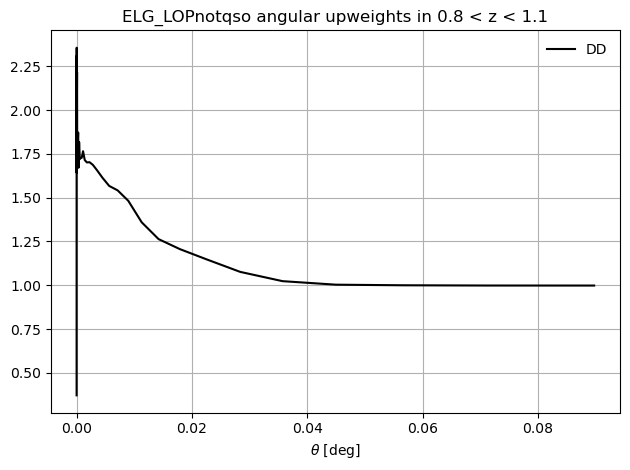

/global/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics/full_shape/fiber_assignment_systematics/abacus-hf-dr2-v2-altmtl/mock0/particle3_angular_upweights_ELG_LOPnotqso_NGC_weight-default-FKP.h5


/tmp/ipykernel_919314/1576085587.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False)


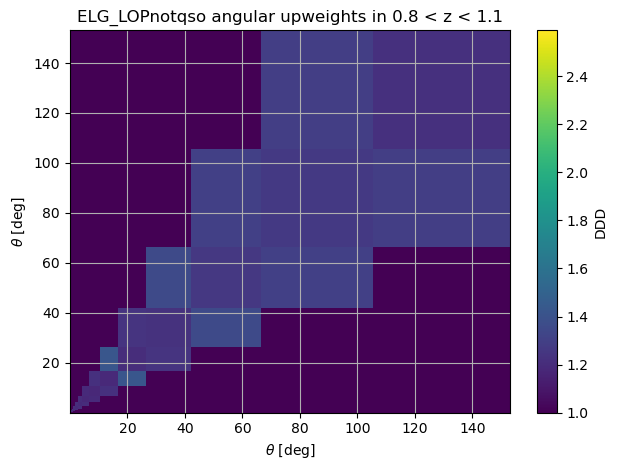

/global/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics/full_shape/fiber_assignment_systematics/abacus-hf-dr2-v2-altmtl/mock0/particle2_angular_upweights_ELG_LOPnotqso_NGC_weight-default-FKP.h5


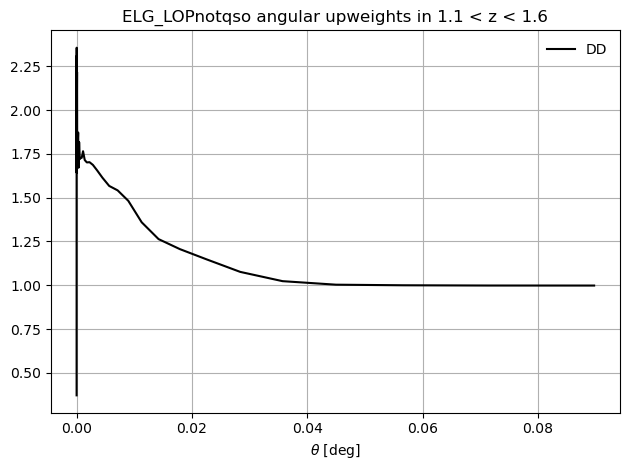

/global/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics/full_shape/fiber_assignment_systematics/abacus-hf-dr2-v2-altmtl/mock0/particle3_angular_upweights_ELG_LOPnotqso_NGC_weight-default-FKP.h5


/tmp/ipykernel_919314/1576085587.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False)


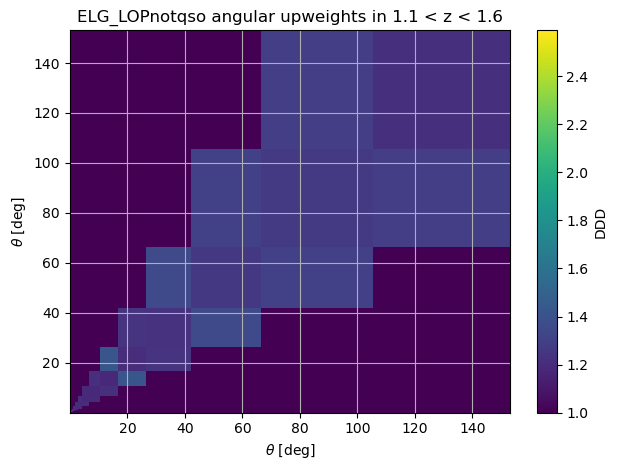

In [2]:
for tracer in ['LRG', 'ELG_LOPnotqso', 'QSO'][:2]:
    for zrange in tools.propose_fiducial('zranges', tracer):
        for kind in ['particle2_angular_upweights', 'particle3_angular_upweights']:
            stats_dir = tools.base_stats_dir
            project = 'full_shape/fiber_assignment_systematics'
            region = 'NGC'
            fn = tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project=project, version='abacus-hf-dr2-v2-altmtl',
                                    tracer=tracer, region=region, weight='default-FKP', imock=0)
            angular = types.read(fn)
            if 'particle2' in kind:
                angular = angular.get('DD')
                fig, ax = plt.subplots()
                ax.plot(angular.coords('theta'), angular.value(), color='k', label='DD')
                ax.set_xlabel(r'$\theta$ [$\mathrm{deg}$]')
                ax.grid(True)
                ax.legend(frameon=False)
                ax.set_title(f'{tracer} angular upweights in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
            elif 'particle3' in kind:
                angular = angular.get('DDD')
                fig, ax = plt.subplots()
                # 2D color map
                X, Y = np.meshgrid(*list(angular.coords().values())[:2])
                Z = angular.value().mean(axis=0)
                pcm = ax.pcolormesh(X, Y, Z, shading='auto')
                fig.colorbar(pcm, ax=ax, label='DDD')
                ax.set_xlabel(r'$\theta$ [$\mathrm{deg}$]')
                ax.set_ylabel(r'$\theta$ [$\mathrm{deg}$]')
                ax.grid(True)
                ax.legend(frameon=False)
                ax.set_title(f'{tracer} angular upweights in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
            basename = f'{kind}_{tracer}_{region}.{ext}'
            plt.tight_layout()
            fig.savefig(plot_dir / basename, bbox_inches='tight', pad_inches=0.1, dpi=200)
            plt.show()
                

### Comparison of altmtl and "on-the-fly complete" mocks

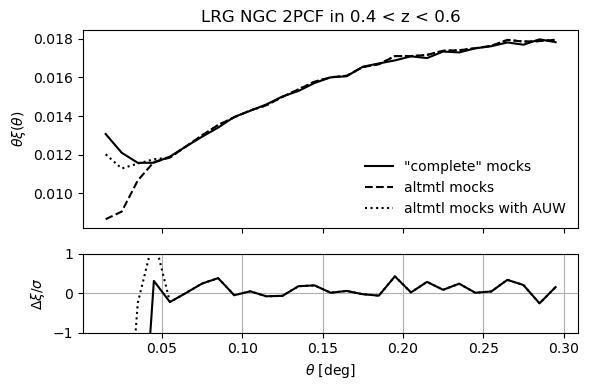

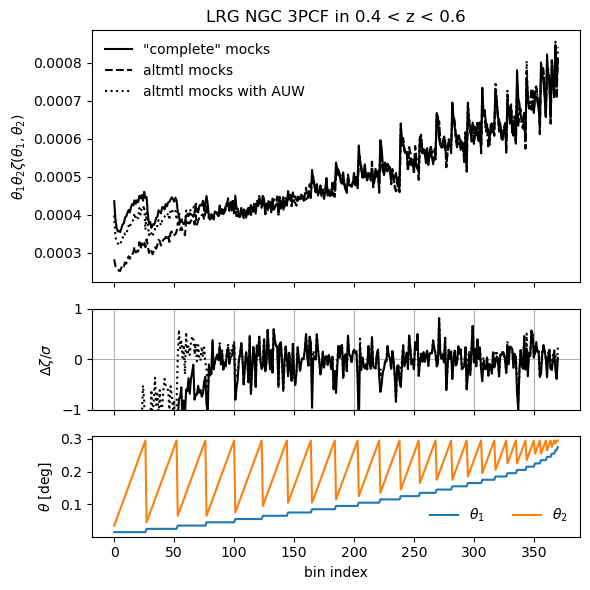

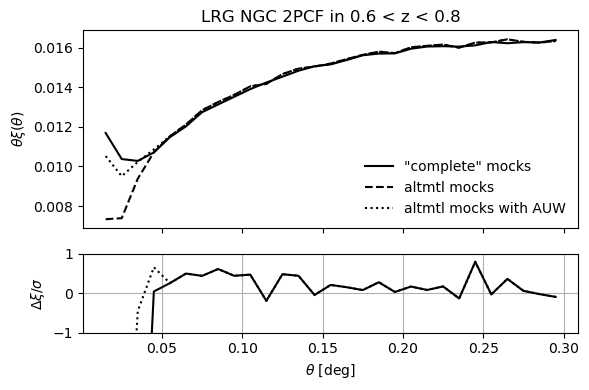

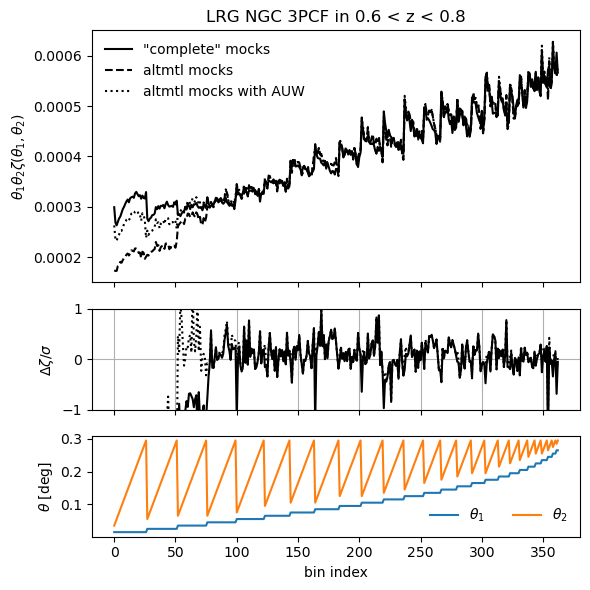

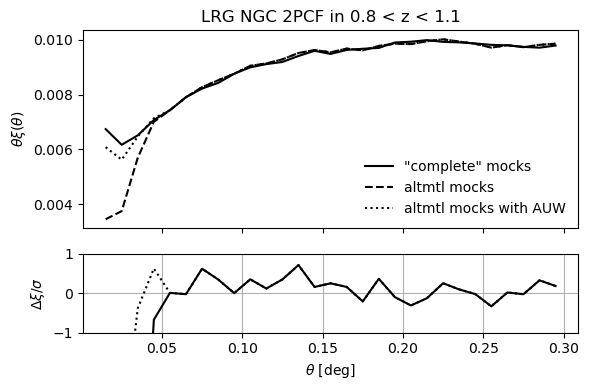

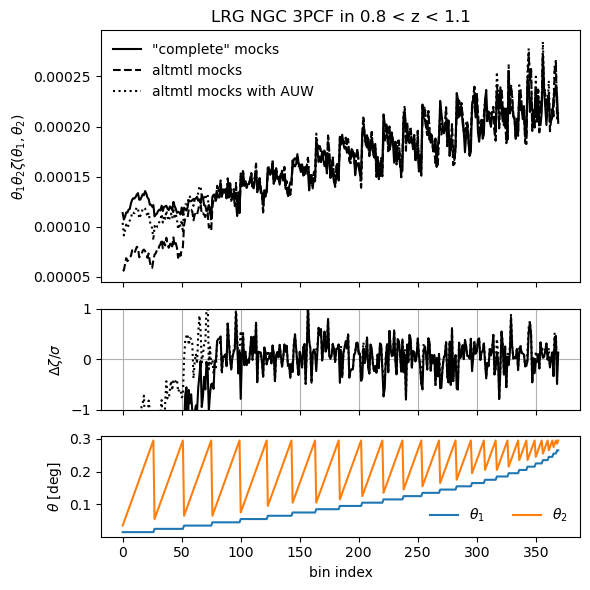

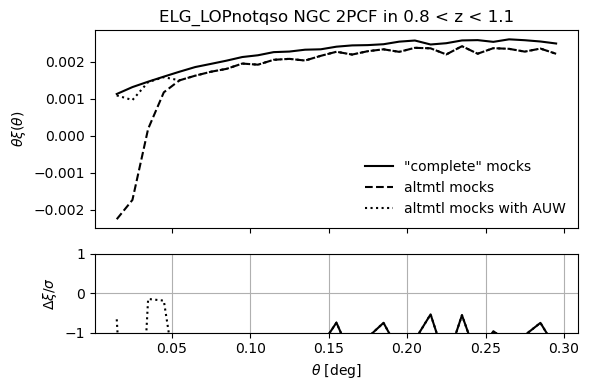

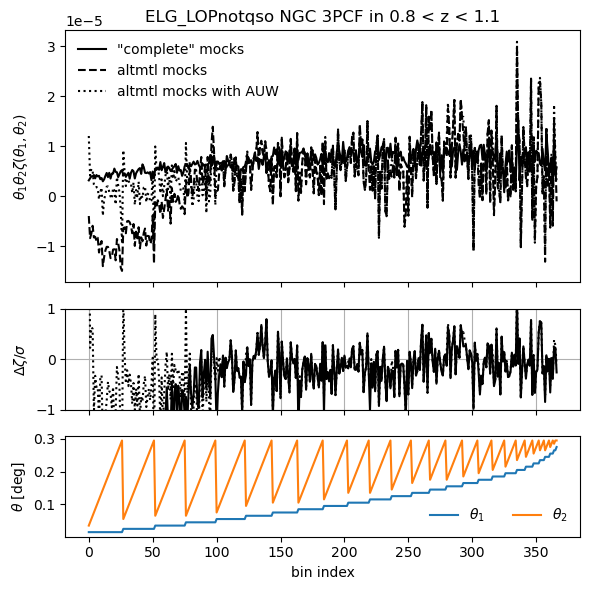

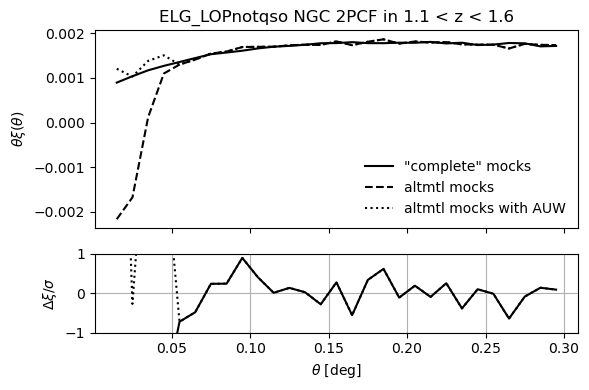

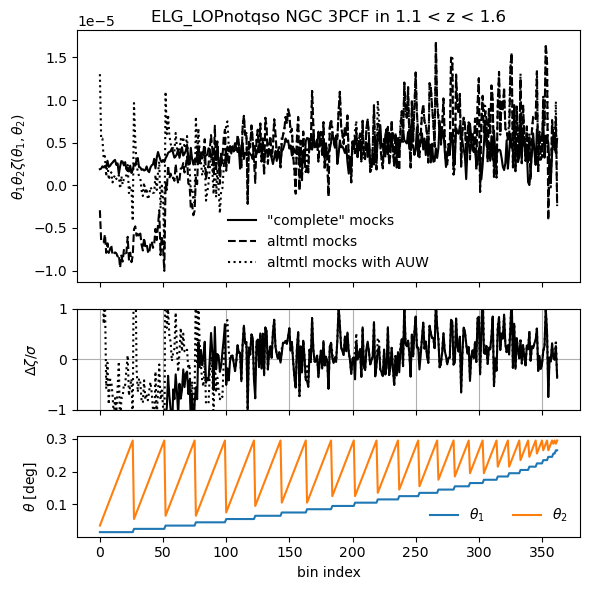

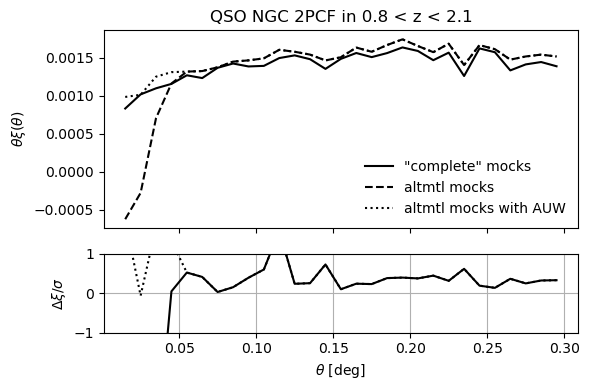

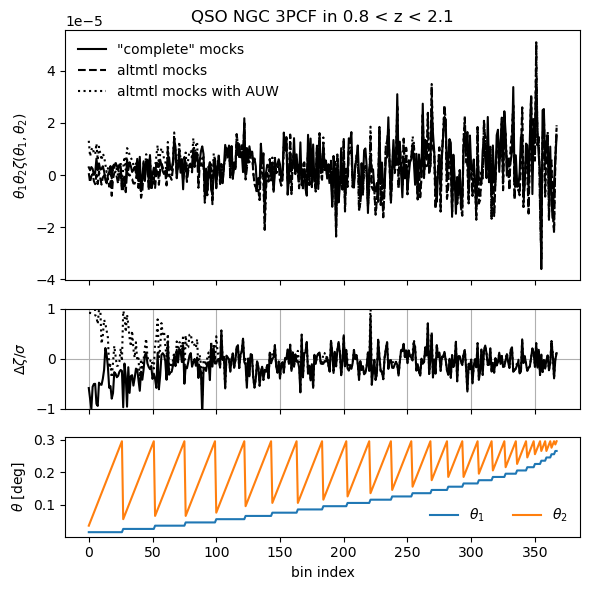

In [3]:
with_auw = True

for tracer in ['LRG', 'ELG_LOPnotqso', 'QSO']:
    for zrange in tools.propose_fiducial('zranges', tracer):
        for kind in ['particle2_correlation', 'particle3_correlation']:
            stats_dir = tools.base_stats_dir
            project = 'full_shape/fiber_assignment_systematics'
            region = 'NGC'

            battrs = {'theta': None}
            nmocks = 9

            fns = [tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project=project, version='abacus-hf-dr2-v2-altmtl', tracer=tracer,
                                      zrange=zrange, region=region, weight='default-FKP', battrs=battrs, imock=imock) for imock in range(nmocks)]
            mocks = [types.read(fn).project() for fn in fns if fn.exists()]
            if 'particle3' in kind: mocks = [mock.ravel() for mock in mocks]
            mean = types.mean(mocks).select(theta=(0.01, 1.))
            #cov = None
            cov = types.cov(mocks).at.observable.match(mean)

            if with_auw:
                fns = [tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project=project, version='abacus-hf-dr2-v2-altmtl', tracer=tracer,
                                          zrange=zrange, region=region, weight='default-FKP', battrs=battrs, imock=imock, auw=True) for imock in range(nmocks)]
                mocks = [types.read(fn).project() for fn in fns if fn.exists()]
                if 'particle3' in kind: mocks = [mock.ravel() for mock in mocks]
                mean_auw = types.mean(mocks).match(mean)

            fns = [tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project=project, version='abacus-hf-dr2-v2-altmtl', tracer=tracer,
                                      zrange=zrange, region=region, weight='default-FKP', battrs=battrs, extra='complete',
                                      imock=imock) for imock in range(nmocks)]
            mocks = [types.read(fn).project() for fn in fns if fn.exists()]
            if 'particle3' in kind: mocks = [mock.ravel() for mock in mocks]
            mean_complete = types.mean(mocks).match(mean)
            nmocks = len(mocks)  # scale error bars
            color = 'k'
        
            if 'particle2' in kind:
                fig, lax = plt.subplots(2, figsize=(6, 4), sharex=True, gridspec_kw={'height_ratios': [2.5, 1]})
                lax[0].set_title(f'{tracer} {region} 2PCF in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
                ax = lax[0]
                ax.set_ylabel(rf'$\theta \xi(\theta)$')
                ax.plot(theta:=mean_complete.coords('theta'), theta * mean_complete.value(), color=color, linestyle='-')
                ax.plot(theta:=mean.coords('theta'), theta * mean.value(), color=color, linestyle='--')
                if with_auw:
                    ax.plot(theta:=mean_auw.coords('theta'), theta * mean_auw.value(), color=color, linestyle=':')
                if cov is not None:
                    ax = lax[1]
                    ax.set_ylabel(rf'$\Delta \xi / \sigma$')
                    ax.grid(True)
                    ax.set_ylim(-1., 1.)
                    std = cov.std() # / nmocks**0.5
                    ax.plot(mean.coords('theta'), (mean.value() - mean_complete.value()) / std, color=color, linestyle='-')
                    if with_auw:
                        ax.plot(mean_auw.coords('theta'), (mean_auw.value() - mean_complete.value()) / std, color=color, linestyle=':')
                ax = lax[0]
                ax.plot([], [], color='k', linestyle='-', label='"complete" mocks')
                ax.plot([], [], color='k', linestyle='--', label='altmtl mocks')
                if with_auw:
                    ax.plot([], [], color='k', linestyle=':', label='altmtl mocks with AUW')
                lax[-1].set_xlabel(r'$\theta$ [$\mathrm{deg}$]')
                ax.legend(frameon=False)

            elif 'particle3' in kind:
                fig, lax = plt.subplots(3, figsize=(6, 6), sharex=True, gridspec_kw={'height_ratios': [2.5, 1, 1]})
                lax[0].set_title(f'{tracer} {region} 3PCF in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
                ax = lax[0]
                ax.set_ylabel(rf'$\theta_1 \theta_2 \zeta(\theta_1, \theta_2)$')
                theta = mean_complete.coords('theta')
                mask = (theta[..., 1] > theta[..., 0]) & (np.abs(theta[..., 1] - theta[..., 0]) > 0.02) & (mean_complete.edges('theta')[..., 0, 0] > 0)
                idx = np.arange(mask.sum())
                ax.plot(idx, (theta.prod(axis=-1) * mean_complete.value())[mask], color=color, linestyle='-')
                ax.plot(idx, (theta.prod(axis=-1) * mean.value())[mask], color=color, linestyle='--')
                if with_auw:
                    ax.plot(idx, (theta.prod(axis=-1) * mean_auw.value())[mask], color=color, linestyle=':')
                if cov is not None:
                    ax = lax[1]
                    ax.set_ylabel(rf'$\Delta \zeta / \sigma$')
                    ax.grid(True)
                    ax.set_ylim(-1., 1.)
                    #ax.set_ylim(-5e4, 5e4)
                    std = cov.std() #/ nmocks**0.5
                    corr_complete = mean_complete
                    ax.plot(idx, (mean.value() - mean_complete.value())[mask] / std[mask], color=color, linestyle='-')
                    if with_auw:
                        ax.plot(idx, (mean_auw.value() - mean_complete.value())[mask] / std[mask], color=color, linestyle=':')
                ax = lax[0]
                ax.plot([], [], color='k', linestyle='-', label='"complete" mocks')
                ax.plot([], [], color='k', linestyle='--', label='altmtl mocks')
                if with_auw:
                    ax.plot([], [], color='k', linestyle=':', label='altmtl mocks with AUW')
                ax.legend(frameon=False)
                for idim in range(theta.shape[1]):
                    lax[-1].plot(idx, theta[mask, idim], color=f'C{idim:d}', label=rf'$\theta_{idim + 1:d}$')
                lax[-1].set_ylabel(r'$\theta$ [$\mathrm{deg}$]')
                lax[-1].set_xlabel(r'bin index')
                lax[-1].legend(frameon=False, ncol=theta.shape[1])

            basename = f'validation_auw_{kind}_theta_{tracer}_z{zrange[0]:.1f}-{zrange[1]:.1f}_{region}.{ext}'
            plt.tight_layout()
            fig.savefig(plot_dir / basename, bbox_inches='tight', pad_inches=0.1, dpi=200)
            plt.show()

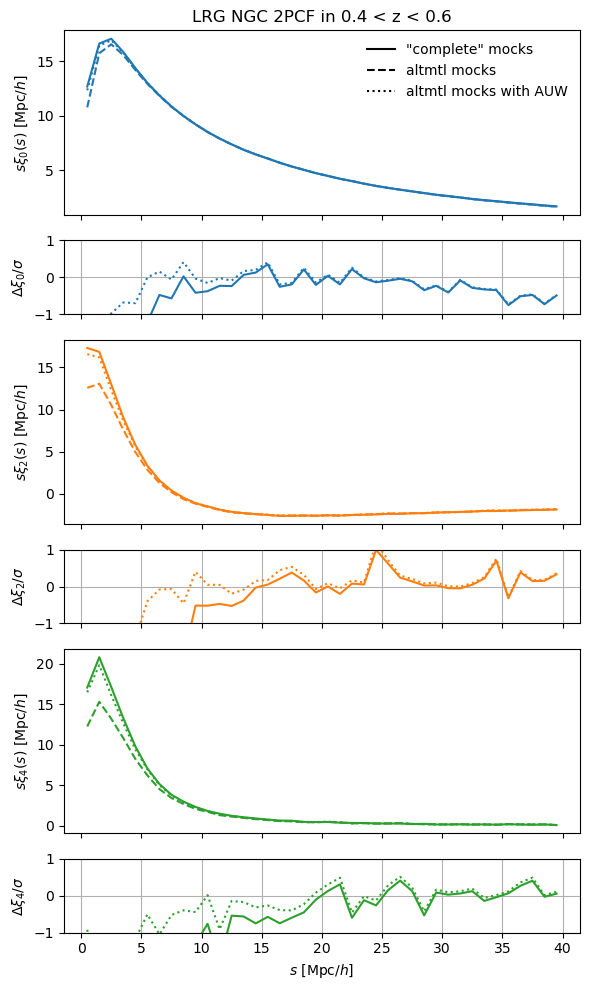

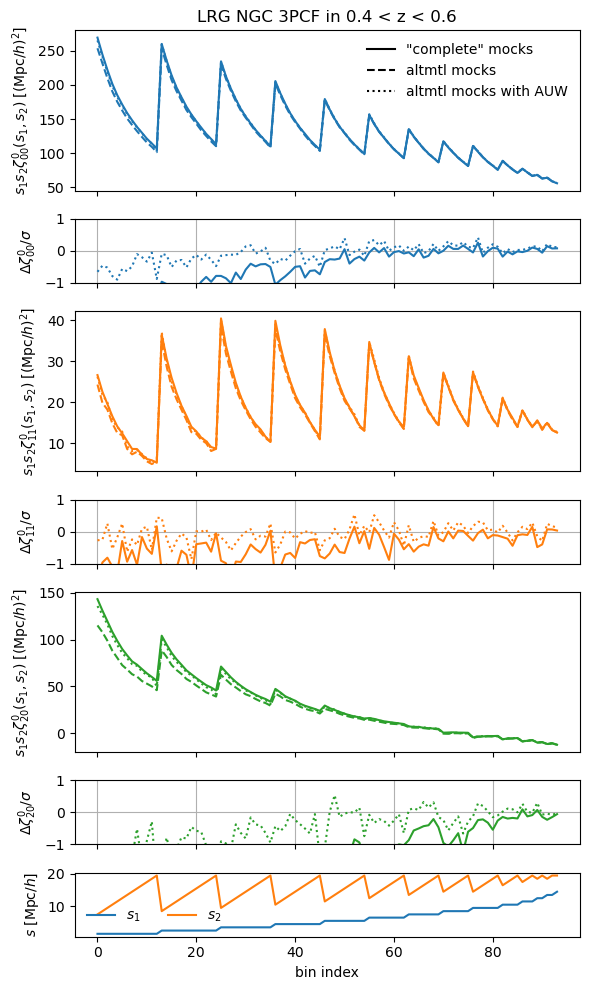

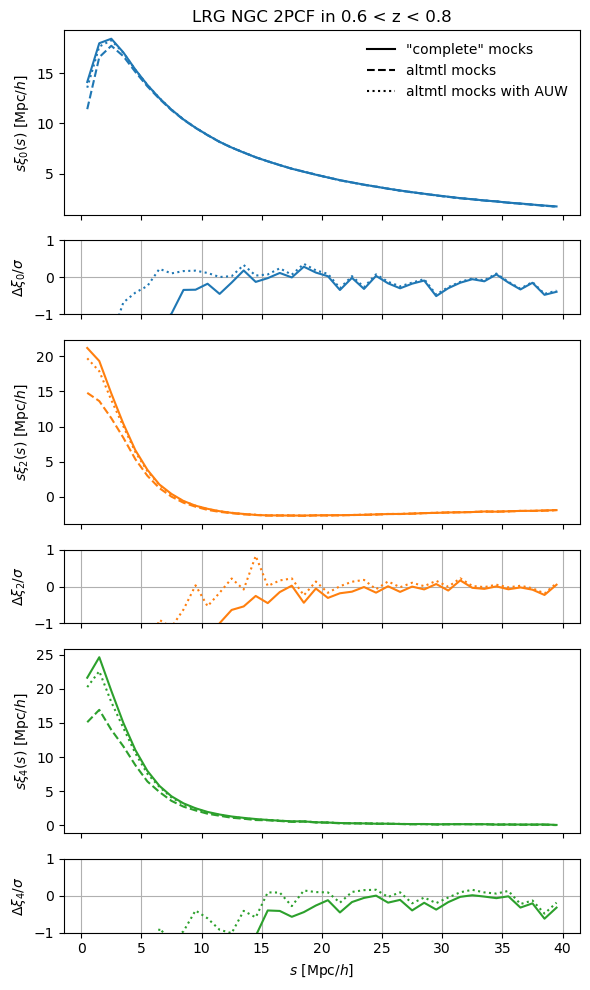

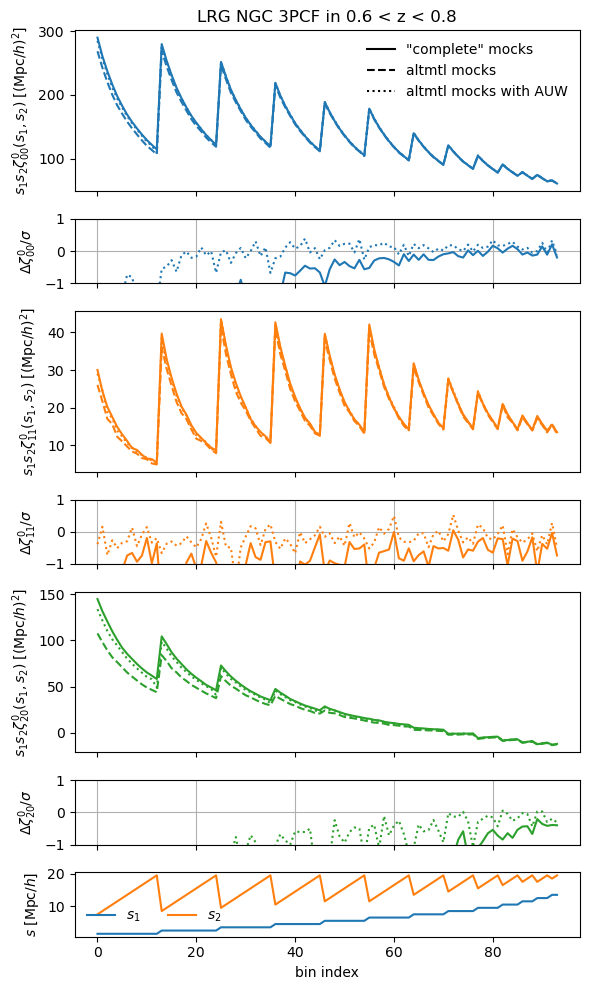

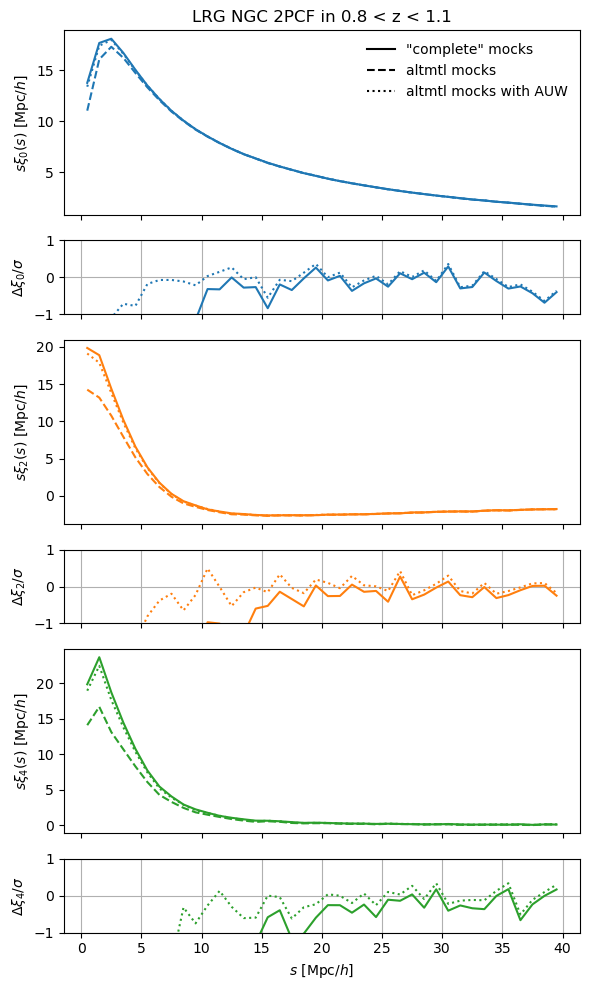

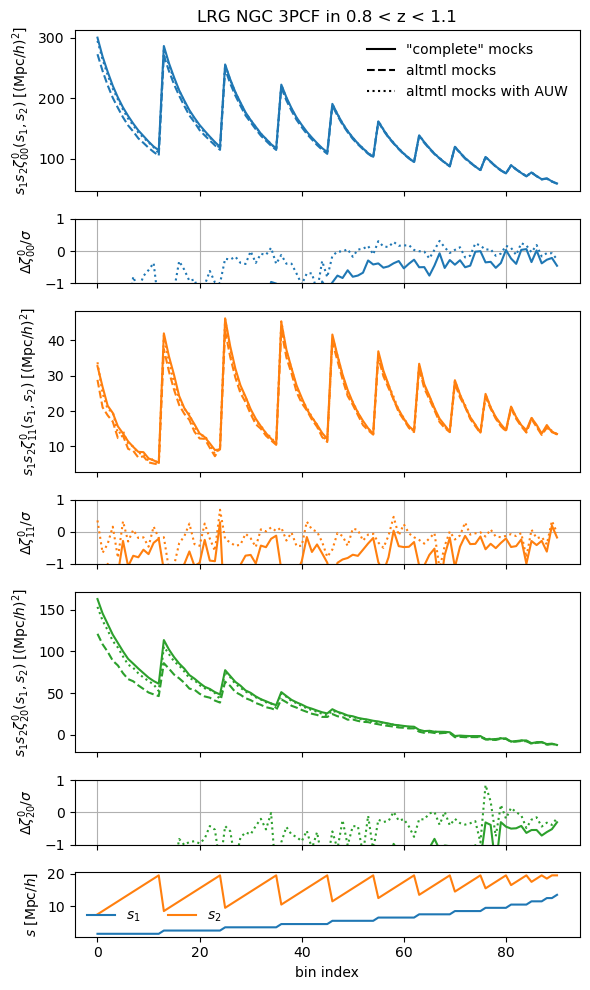

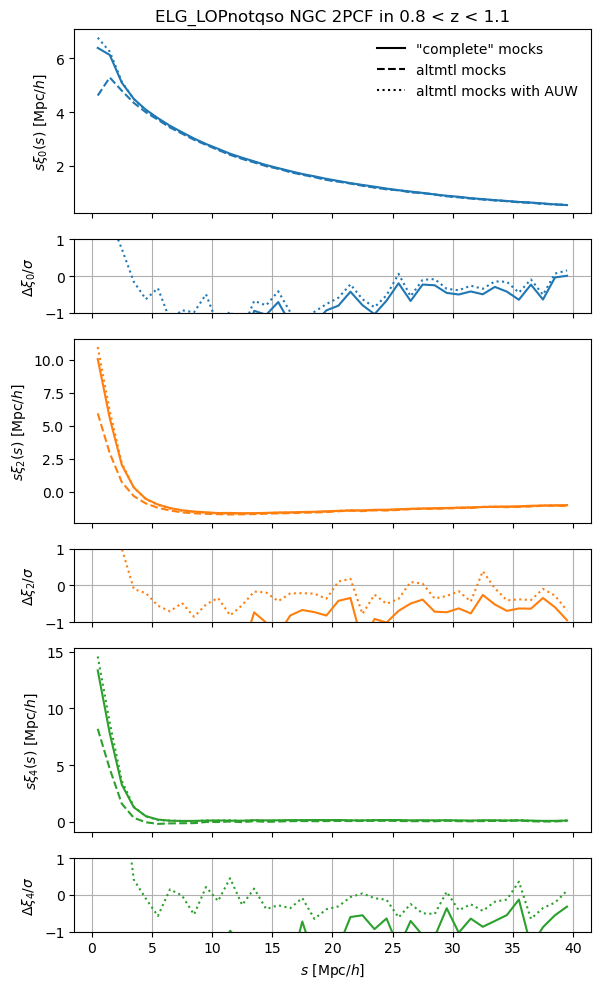

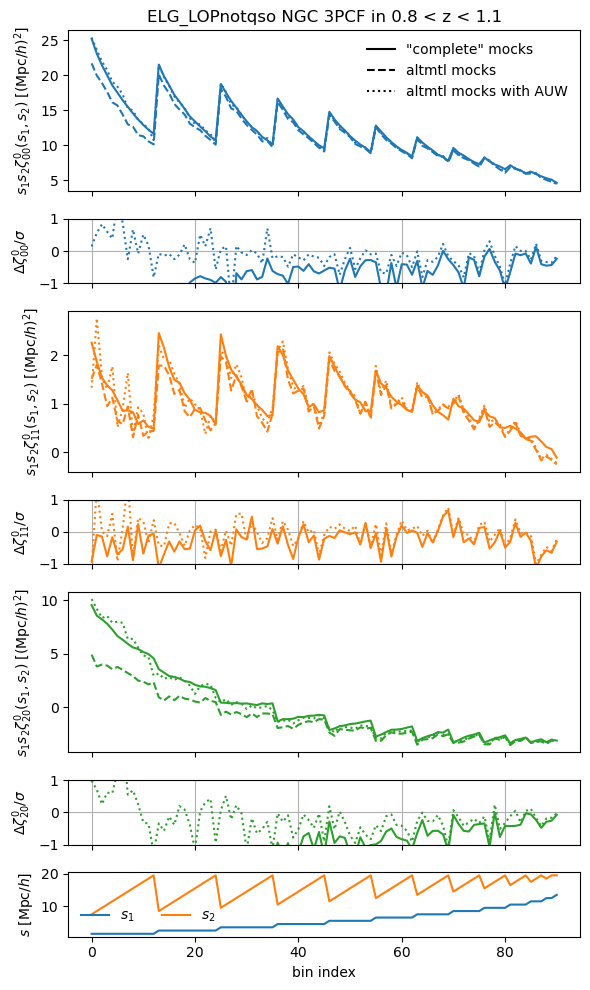

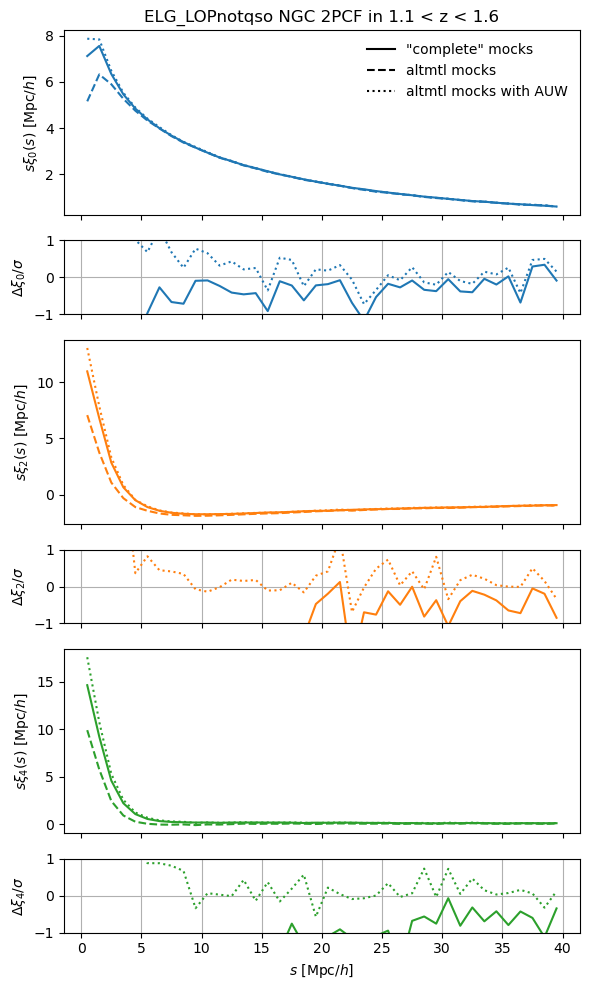

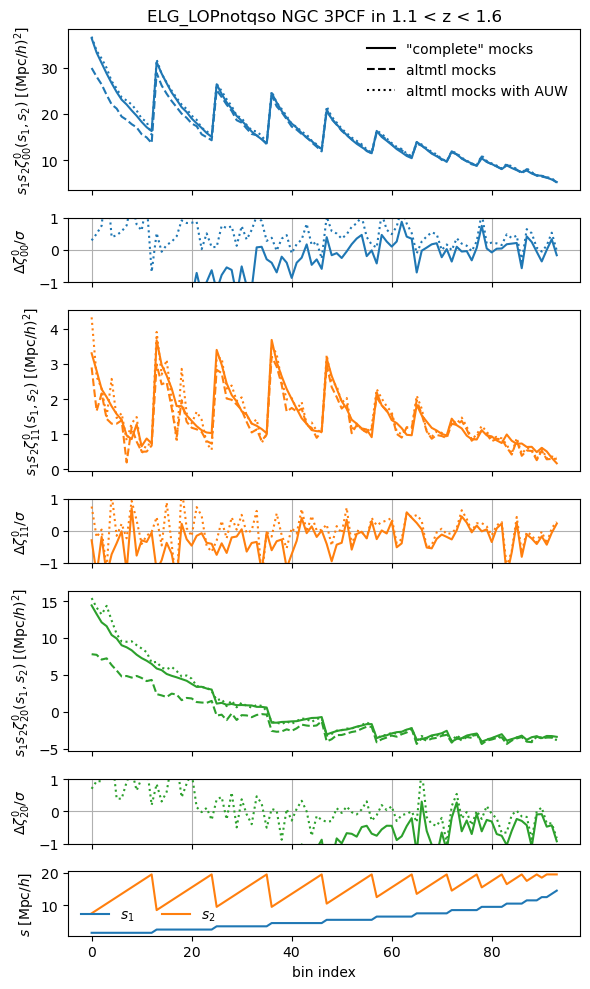

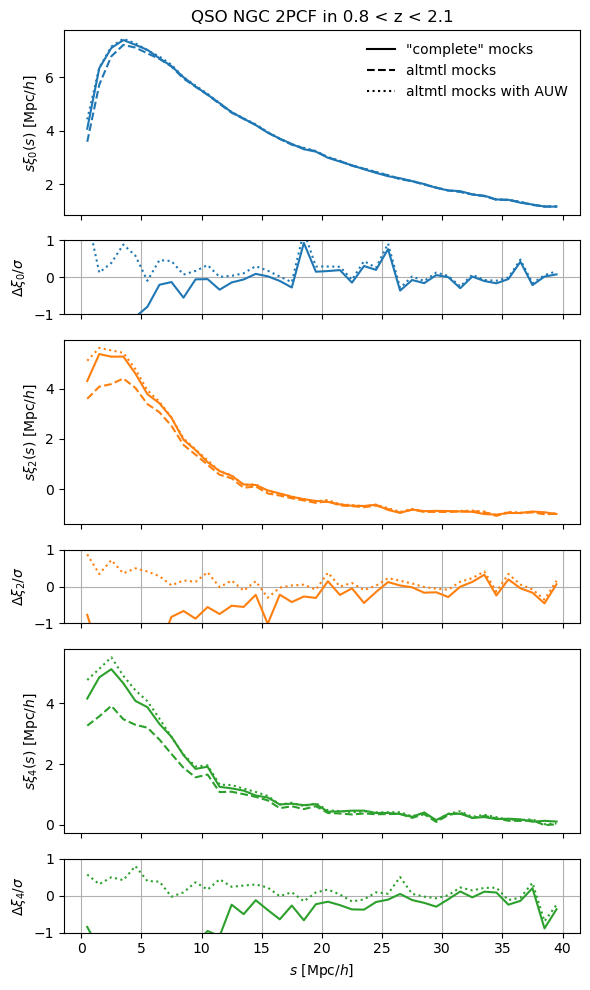

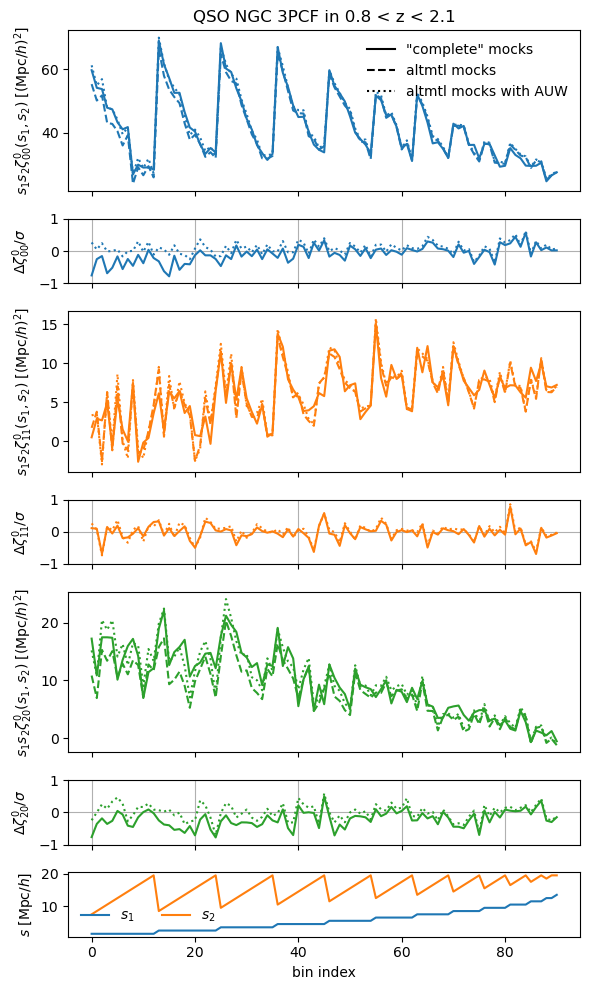

In [4]:
with_auw = True

for tracer in ['LRG', 'ELG_LOPnotqso', 'QSO']:
    for zrange in tools.propose_fiducial('zranges', tracer):
        for kind in ['particle2_correlation', 'particle3_correlation']:
            stats_dir = tools.base_stats_dir
            project = 'full_shape/fiber_assignment_systematics'
            region = 'NGC'

            ells = (0, 2, 4)
            if 'particle3' in kind:
                ells = [(0, 0, 0), (1, 1, 0), (2, 0, 0)]
            nmocks = 9
            fns = [tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project=project, version='abacus-hf-dr2-v2-altmtl', tracer=tracer,
                                      zrange=zrange, region=region, weight='default-FKP', imock=imock) for imock in range(nmocks)]
            mocks = [types.read(fn).project(ells=ells) for fn in fns if fn.exists()]
            mean = types.mean(mocks)
            #cov = None
            cov = types.cov(mocks)

            if with_auw:
                fns = [tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project=project, version='abacus-hf-dr2-v2-altmtl', tracer=tracer,
                                          zrange=zrange, region=region, weight='default-FKP', imock=imock, auw=True) for imock in range(nmocks)]
                mocks = [types.read(fn).project(ells=ells) for fn in fns if fn.exists()]
                mean_auw = types.mean(mocks).match(mean)

            fns = [tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project=project, version='abacus-hf-dr2-v2-altmtl', tracer=tracer,
                                      zrange=zrange, region=region, weight='default-FKP', extra='complete',
                                      imock=imock) for imock in range(nmocks)]
            mocks = [types.read(fn).project(ells=ells) for fn in fns if fn.exists()]
            mean_complete = types.mean(mocks).match(mean)
            nmocks = len(mocks)  # scale error bars
        
            if 'particle2' in kind:
                ells = mean.ells
                fig, lax = plt.subplots(len(ells) * 2, figsize=(6, 10), sharex=True, gridspec_kw={'height_ratios': [2.5, 1] * len(ells)})
                lax[0].set_title(f'{tracer} {region} 2PCF in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
                for ill, ell in enumerate(mean.ells):
                    ax = lax[2 * ill]
                    ax.set_ylabel(rf'$s \xi_{ell:d}(s)$ [$\mathrm{{Mpc}}/h$]')
                    color = f'C{ill:d}'
                    pole = mean_complete.get(ell)
                    ax.plot(s:=pole.coords('s'), s * pole.value(), color=color, linestyle='-')
                    pole = mean.get(ell)
                    ax.plot(s:=pole.coords('s'), s * pole.value(), color=color, linestyle='--')
                    if with_auw:
                        pole = mean_auw.get(ell)
                        ax.plot(s:=pole.coords('s'), s * pole.value(), color=color, linestyle=':')
                    if cov is not None:
                        ax = lax[2 * ill + 1]
                        ax.set_ylabel(rf'$\Delta \xi_{ell:d} / \sigma$')
                        ax.grid(True)
                        ax.set_ylim(-1., 1.)
                        pole = mean.get(ell)
                        std = cov.at.observable.get(ell).std() # / nmocks**0.5
                        pole_complete = mean_complete.get(ell)
                        ax.plot(pole.coords('s'), (pole.value() - pole_complete.value()) / std, color=color, linestyle='-')
                        if with_auw:
                            pole = mean_auw.get(ell)
                            ax.plot(pole.coords('s'), (pole.value() - pole_complete.value()) / std, color=color, linestyle=':')
                ax = lax[0]
                ax.plot([], [], color='k', linestyle='-', label='"complete" mocks')
                ax.plot([], [], color='k', linestyle='--', label='altmtl mocks')
                if with_auw:
                    ax.plot([], [], color='k', linestyle=':', label='altmtl mocks with AUW')
                lax[-1].set_xlabel(r'$s$ [$\mathrm{Mpc}/h$]')
                ax.legend(frameon=False)

            elif 'particle3' in kind:
                ells = mean.ells
                fig, lax = plt.subplots(len(ells) * 2 + 1, figsize=(6, 10), sharex=True, gridspec_kw={'height_ratios': [2.5, 1] * len(ells) + [1]})
                lax[0].set_title(f'{tracer} {region} 3PCF in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
                for ill, ell in enumerate(ells):
                    ax = lax[2 * ill]
                    ax.set_ylabel(rf'$s_1 s_2 \zeta_{{{ell[0]:d}{ell[1]:d}}}^{{{ell[2]:d}}}(s_1, s_2)$ [$(\mathrm{{Mpc}}/h)^2$]')
                    color = f'C{ill:d}'
                    pole = mean_complete.get(ell).ravel()
                    s = pole.coords('s')
                    mask = (s[..., 1] > s[..., 0]) & (np.abs(s[..., 1] - s[..., 0]) > 5.) & (pole.edges('s')[..., 0, 0] > 0)
                    idx = np.arange(mask.sum())
                    ax.plot(idx, (s.prod(axis=-1) * pole.value())[mask], color=color, linestyle='-')
                    pole = mean.get(ell).ravel()
                    ax.plot(idx, (s.prod(axis=-1) * pole.value())[mask], color=color, linestyle='--')
                    if with_auw:
                        pole = mean_auw.get(ell).ravel()
                        ax.plot(idx, (s.prod(axis=-1) * pole.value())[mask], color=color, linestyle=':')
                    if cov is not None:
                        ax = lax[2 * ill + 1]
                        ax.set_ylabel(rf'$\Delta \zeta_{{{ell[0]:d}{ell[1]:d}}}^{{{ell[2]:d}}} / \sigma$')
                        ax.grid(True)
                        ax.set_ylim(-1., 1.)
                        #ax.set_ylim(-5e4, 5e4)
                        pole = mean.get(ell).ravel()
                        std = cov.at.observable.get(ell).std() #/ nmocks**0.5
                        pole_complete = mean_complete.get(ell).ravel()
                        ax.plot(idx, (pole.value() - pole_complete.value())[mask] / std[mask], color=color, linestyle='-')
                        if with_auw:
                            pole = mean_auw.get(ell).ravel()
                            ax.plot(idx, (pole.value() - pole_complete.value())[mask] / std[mask], color=color, linestyle=':')
                ax = lax[0]
                ax.plot([], [], color='k', linestyle='-', label='"complete" mocks')
                ax.plot([], [], color='k', linestyle='--', label='altmtl mocks')
                if with_auw:
                    ax.plot([], [], color='k', linestyle=':', label='altmtl mocks with AUW')
                ax.legend(frameon=False)
                for idim in range(s.shape[1]):
                    lax[-1].plot(idx, s[mask, idim], color=f'C{idim:d}', label=f'$s_{idim + 1:d}$')
                lax[-1].set_ylabel(r'$s$ [$\mathrm{Mpc}/h$]')
                lax[-1].set_xlabel(r'bin index')
                lax[-1].legend(frameon=False, ncol=s.shape[1])

            basename = f'validation_auw_{kind}_{tracer}_z{zrange[0]:.1f}-{zrange[1]:.1f}_{region}.{ext}'
            plt.tight_layout()
            fig.savefig(plot_dir / basename, bbox_inches='tight', pad_inches=0.1, dpi=200)
            plt.show()

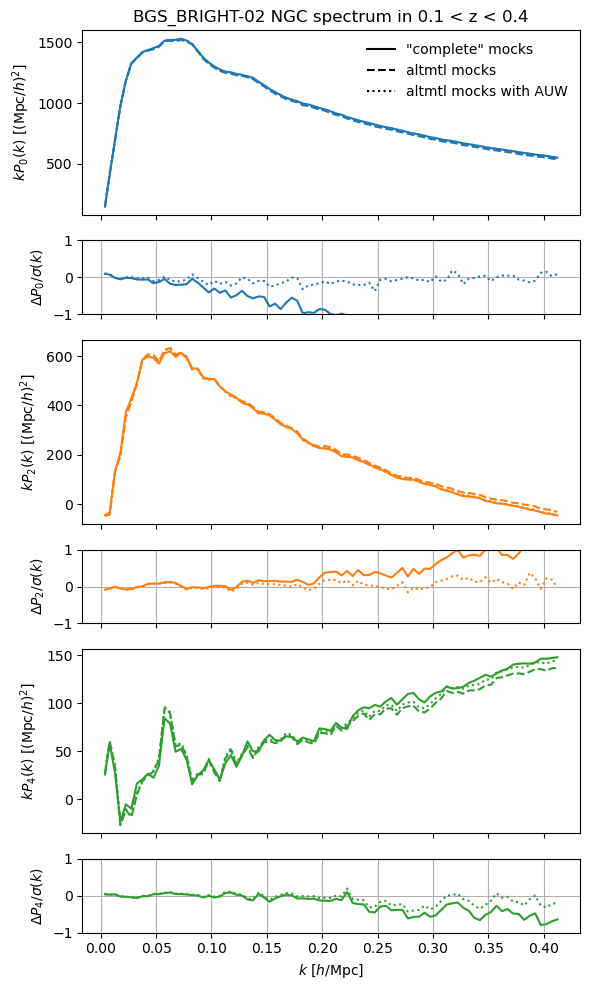

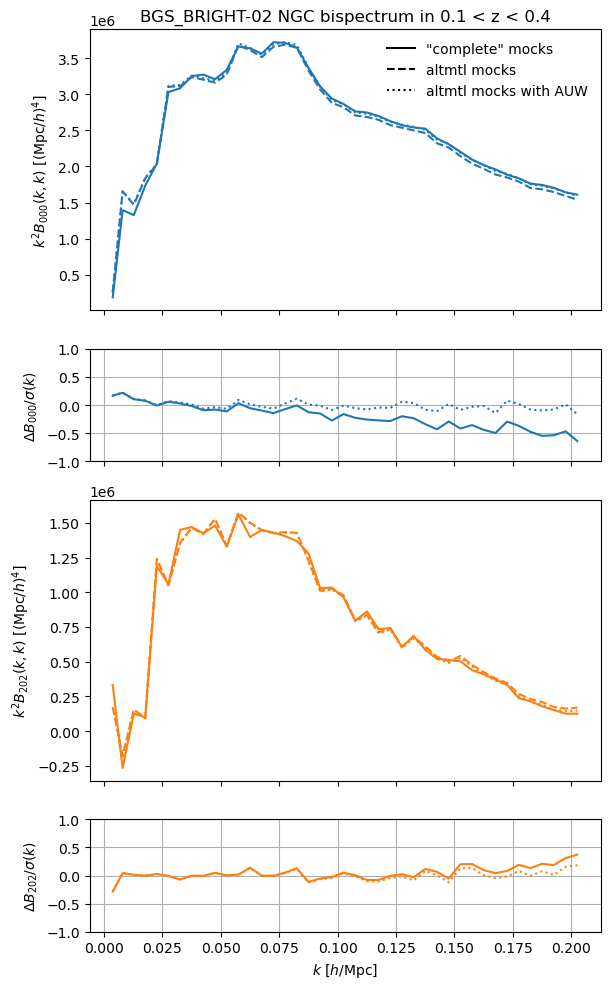

In [5]:
with_auw = True

for tracer in ['BGS_BRIGHT-21.35', 'LRG', 'ELG_LOPnotqso', 'QSO'][:1]:
    for zrange in tools.propose_fiducial('zranges', tracer):
        for kind in ['mesh2_spectrum', 'mesh3_spectrum']:
            stats_dir = tools.base_stats_dir
            project = 'full_shape/fiber_assignment_systematics'
            region = 'NGC'

            version = 'holi-v3-altmtl'
            if 'BGS' in tracer:
                version = 'holi-bgs-altmtl'
                tracer = 'BGS_BRIGHT-21.35'
            fns = [tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project='full_shape/base', version=version, tracer=tracer,
                                      zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal', imock=imock) for imock in range(50)]

            mocks = [types.read(fn) for fn in fns if fn.exists()]
            cov = types.cov(mocks)
            cov = cov.at.observable.select(k=slice(0, None, 5 if 'mesh2' in kind else 1))
            mean = cov.observable

            nmocks = 25
            version = 'abacus-hf-dr2-v2-altmtl'
            if 'BGS' in tracer:
                version = 'abacus-2ndgen-dr2-altmtl'
                tracer = 'BGS_BRIGHT-02'
            fns = [tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project=project, version=version, tracer=tracer,
                                      zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal', imock=imock) for imock in range(nmocks)]
            mocks = [types.read(fn) for fn in fns if fn.exists()]
            mean = types.mean(mocks).match(mean)

            if with_auw:
                fns = [tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project=project, version=version, tracer=tracer,
                                          zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal', imock=imock, auw=True) for imock in range(nmocks)]
                mocks = [types.read(fn) for fn in fns if fn.exists()]
                mean_auw = types.mean(mocks).match(mean)

            fns = [tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project=project, version=version, tracer=tracer,
                                      zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal', extra='complete',
                                      imock=imock) for imock in range(nmocks)]
            mocks = [types.read(fn) for fn in fns if fn.exists()]
            mean_complete = types.mean(mocks).match(mean)
            nmocks = len(mocks)  # scale error bars

            if 'mesh2' in kind:
                ells = mean.ells
                fig, lax = plt.subplots(len(ells) * 2, figsize=(6, 10), sharex=True, gridspec_kw={'height_ratios': [2.5, 1] * len(ells)})
                lax[0].set_title(f'{tracer} {region} spectrum in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
                for ill, ell in enumerate(mean.ells):
                    ax = lax[2 * ill]
                    ax.set_ylabel(rf'$k P_{ell:d}(k)$ [$(\mathrm{{Mpc}}/h)^2$]')
                    color = f'C{ill:d}'
                    pole = mean_complete.get(ell)
                    ax.plot(k:=pole.coords('k'), k * pole.value(), color=color, linestyle='-')
                    pole = mean.get(ell)
                    ax.plot(k:=pole.coords('k'), k * pole.value(), color=color, linestyle='--')
                    if with_auw:
                        pole = mean_auw.get(ell)
                        ax.plot(k:=pole.coords('k'), k * pole.value(), color=color, linestyle=':')
                    ax = lax[2 * ill + 1]
                    ax.set_ylabel(rf'$\Delta P_{ell:d} / \sigma(k)$')
                    ax.grid(True)
                    ax.set_ylim(-1., 1.)
                    pole = mean.get(ell)
                    std = cov.at.observable.get(ell).std() # / nmocks**0.5
                    pole_complete = mean_complete.get(ell)
                    ax.plot(pole.coords('k'), (pole.value() - pole_complete.value()) / std, color=color, linestyle='-')
                    if with_auw:
                        pole = mean_auw.get(ell)
                        ax.plot(pole.coords('k'), (pole.value() - pole_complete.value()) / std, color=color, linestyle=':')
                ax = lax[0]
                ax.plot([], [], color='k', linestyle='-', label='"complete" mocks')
                ax.plot([], [], color='k', linestyle='--', label='altmtl mocks')
                if with_auw:
                    ax.plot([], [], color='k', linestyle=':', label='altmtl mocks with AUW')
                lax[-1].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
                ax.legend(frameon=False)

            elif 'mesh3' in kind:
                ells = mean.ells
                fig, lax = plt.subplots(len(ells) * 2, figsize=(6, 10), sharex=True, gridspec_kw={'height_ratios': [2.5, 1] * len(ells)})
                lax[0].set_title(f'{tracer} {region} bispectrum in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
                for ill, ell in enumerate(ells):
                    ax = lax[2 * ill]
                    ax.set_ylabel(rf'$k^2 B_{{{ell[0]:d}{ell[1]:d}{ell[2]:d}}}(k, k)$ [$(\mathrm{{Mpc}}/h)^4$]')
                    color = f'C{ill:d}'
                    pole = mean_complete.get(ell)
                    ax.plot(k:=pole.coords('k')[..., 0], k**2 * pole.value(), color=color, linestyle='-')
                    pole = mean.get(ell)
                    ax.plot(k:=pole.coords('k')[..., 0], k**2 * pole.value(), color=color, linestyle='--')
                    if with_auw:
                        pole = mean_auw.get(ell)
                        ax.plot(k:=pole.coords('k')[..., 0], k**2 * pole.value(), color=color, linestyle=':')
                    ax = lax[2 * ill + 1]
                    ax.set_ylabel(rf'$\Delta B_{{{ell[0]:d}{ell[1]:d}{ell[2]:d}}} / \sigma(k)$')
                    ax.grid(True)
                    ax.set_ylim(-1., 1.)
                    #ax.set_ylim(-5e4, 5e4)
                    pole = mean.get(ell)
                    std = cov.at.observable.get(ell).std() #/ nmocks**0.5
                    pole_complete = mean_complete.get(ell)
                    ax.plot(k, (pole.value() - pole_complete.value()) / std, color=color, linestyle='-')
                    if with_auw:
                        pole = mean_auw.get(ell)
                        ax.plot(k, (pole.value() - pole_complete.value()) / std, color=color, linestyle=':')
                ax = lax[0]
                ax.plot([], [], color='k', linestyle='-', label='"complete" mocks')
                ax.plot([], [], color='k', linestyle='--', label='altmtl mocks')
                if with_auw:
                    ax.plot([], [], color='k', linestyle=':', label='altmtl mocks with AUW')
                lax[-1].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
                ax.legend(frameon=False)

            basename = f'validation_auw_{kind}_{tracer}_z{zrange[0]:.1f}-{zrange[1]:.1f}_{region}.{ext}'
            plt.tight_layout()
            fig.savefig(plot_dir / basename, bbox_inches='tight', pad_inches=0.1, dpi=200)
            plt.show()

### Comparison of window-convolved box mocks and altmtl (w/o AUW) mocks

alpha value [0.00064016]


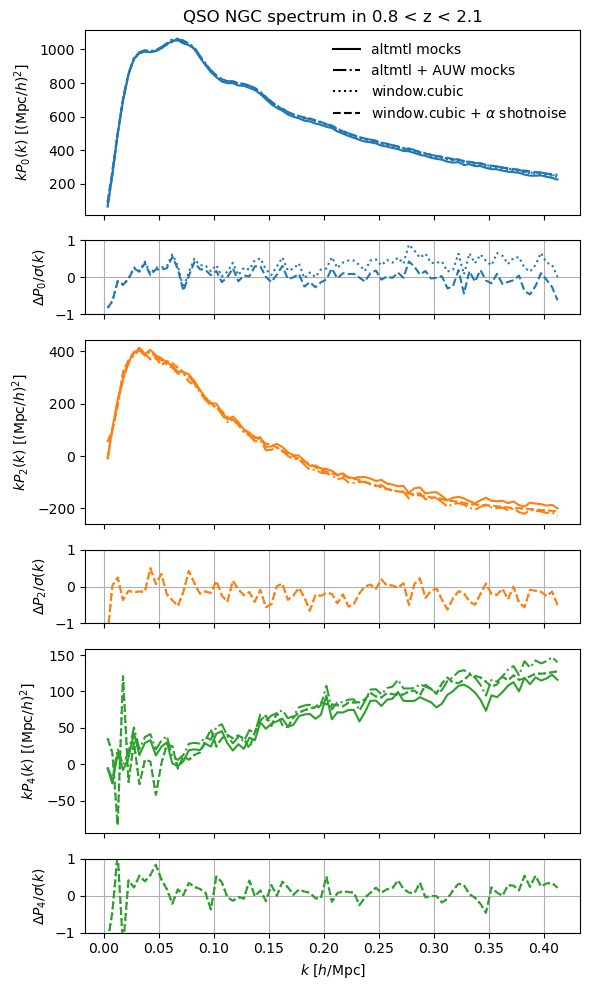

alpha value [3.46922817e-05]


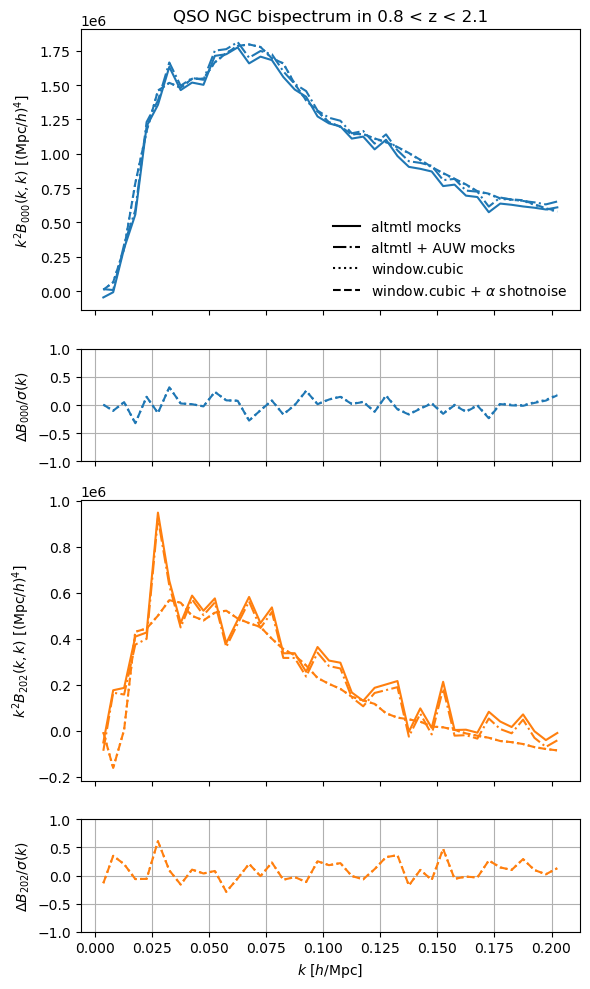

In [6]:
for tracer in ['LRG', 'ELG', 'QSO'][2:]:
    for zrange in tools.propose_fiducial('zranges', tracer):
        for kind in ['mesh2_spectrum', 'mesh3_spectrum']:
            nmocks = 25
            region = 'NGC'
            zsnap = box_tools.get_zsnap_from_z(tracer, zrange, version='abacus-hf-v2')
            stracer = tools.get_simple_tracer(tracer)
            stats_dir = tools.base_stats_dir
            hod = {'LRG': 'base_B', 'ELG': 'base_conf_nfwexp', 'QSO': 'base'}[stracer]
            fns = [box_tools.get_box_stats_fn(stats_dir=stats_dir, project='full_shape/box_window_function_validation', kind=kind, version='abacus-hf-v2', tracer=stracer,
                                              zsnap=zsnap, cosmo='000', hod=hod, los='z', basis='sugiyama', imock=imock) for imock in range(nmocks)]
            mocks_box = [types.read(fn) for fn in fns if fn.exists()]
            mean_box = types.mean(mocks_box)

            ftracer = tools.get_full_tracer(tracer, version='abacus-hf-dr2-v2-altmtl')
            fns = [tools.get_stats_fn(stats_dir=stats_dir, project='full_shape/fiber_assignment_systematics', kind=kind, version='abacus-hf-dr2-v2-altmtl', tracer=ftracer,
                                      zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal', imock=imock) for imock in range(nmocks)]
            mocks_cutsky = [types.read(fn) for fn in fns if fn.exists()]
            mean_altmtl = types.mean(mocks_cutsky).select(k=slice(0, None, 5 if 'mesh2' in kind else 1))

            fns = [tools.get_stats_fn(stats_dir=stats_dir, project='full_shape/fiber_assignment_systematics', kind=kind, version='abacus-hf-dr2-v2-altmtl', tracer=ftracer,
                                      zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal', auw=True, imock=imock) for imock in range(nmocks)]
            mocks_cutsky = [types.read(fn) for fn in fns if fn.exists()]
            mean_altmtl_auw = types.mean(mocks_cutsky).match(mean_altmtl)

            fns = [tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project='full_shape/base', version='holi-v3-altmtl', tracer=ftracer,
                                      zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal', imock=imock) for imock in range(50)]
            mocks = [types.read(fn) for fn in fns if fn.exists()]
            cov = types.cov(mocks)
            cov = cov.at.observable.match(mean_altmtl)

            fn = tools.get_stats_fn(stats_dir=stats_dir, project='full_shape/fiber_assignment_systematics', kind=f'window_{kind}', version='abacus-hf-dr2-v2-altmtl', tracer=ftracer,
                                    zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal', imock=0)
            window_cutsky = types.read(fn).at.observable.match(mean_altmtl)
            mean_box_interp = []
            for label, pole in window_cutsky.theory.items():
                pole_box = mean_box.get(ells=label['ells'])
                if 'mesh3' in kind:
                    pole_box = pole_box.unravel()
                    from scipy import interpolate
                    mask1, mask2 = [np.any(pole_box.values('nmodes') > 0, axis=axis) for axis in [1, 0]]
                    spline = interpolate.RectBivariateSpline(pole_box.coords('k1')[mask1], pole_box.coords('k2')[mask2], pole_box.value()[np.ix_(mask1, mask2)], kx=1, ky=1, s=0)
                    pole = spline(*pole.coords('k').T, grid=False)
                else:
                    mask = pole_box.values('nmodes') > 0
                    pole = np.interp(pole.coords('k'), pole_box.coords('k')[mask], pole_box.value()[mask])
                mean_box_interp.append(pole)
            mean_box_interp = window_cutsky.theory.clone(value=np.concatenate(mean_box_interp))
            mean_box_conv = window_cutsky.dot(mean_box_interp, return_type=None)
            
            shotnoise = window_cutsky.theory.clone(value=0. * window_cutsky.theory.value()).value(concatenate=False)
            shotnoise[0] += next(iter(mean_altmtl_auw)).values('shotnoise').mean()
            shotnoise = window_cutsky.dot(np.concatenate(shotnoise), return_type='nparray')[None, ...]
            precision = np.diag(1. / cov.std())
            # Solve d\chi^2 / drescale = 0, theory = rescale * shotnoise, data = mean_cutsky - mean_box_conv
            rescale = np.linalg.solve(shotnoise.dot(precision).dot(shotnoise.T), shotnoise.dot(precision).dot(mean_altmtl_auw.value() - mean_box_conv.value()))
            print(f'alpha value {rescale}')
            mean_box_conv_shotnoise = mean_box_conv.clone(value=mean_box_conv.value() + rescale.dot(shotnoise))

            nmocks = min(len(mocks_box), len(mocks_cutsky))  # scale error bars
            if 'mesh2' in kind:
                ells = mean_altmtl.ells
                fig, lax = plt.subplots(len(ells) * 2, figsize=(6, 10), sharex=True, gridspec_kw={'height_ratios': [2.5, 1] * len(ells)})
                lax[0].set_title(f'{tracer} {region} spectrum in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
                for ill, ell in enumerate(ells):
                    ax = lax[2 * ill]
                    ax.set_ylabel(rf'$k P_{ell:d}(k)$ [$(\mathrm{{Mpc}}/h)^2$]')
                    color = f'C{ill:d}'
                    pole = mean_altmtl.get(ell)
                    ax.plot(k:=pole.coords('k'), k * pole.value(), color=color, linestyle='-')
                    pole = mean_altmtl_auw.get(ell)
                    ax.plot(k:=pole.coords('k'), k * pole.value(), color=color, linestyle='-.')
                    pole = mean_box_conv.get(ell)
                    ax.plot(k:=pole.coords('k'), k * pole.value(), color=color, linestyle=':')
                    pole = mean_box_conv_shotnoise.get(ell)
                    ax.plot(k:=pole.coords('k'), k * pole.value(), color=color, linestyle='--')
                    ax = lax[2 * ill + 1]
                    ax.set_ylabel(rf'$\Delta P_{ell:d} / \sigma(k)$')
                    ax.grid(True)
                    ax.set_ylim(-1., 1.)
                    std = cov.at.observable.get(ell).std()
                    pole_cutsky = mean_altmtl_auw.get(ell)
                    pole = mean_box_conv.get(ell)
                    ax.plot(pole.coords('k'), (pole_cutsky.value() - pole.value()) / std, color=color, linestyle=':')
                    pole = mean_box_conv_shotnoise.get(ell)
                    ax.plot(pole.coords('k'), (pole_cutsky.value() - pole.value()) / std, color=color, linestyle='--')
                ax = lax[0]
                ax.plot([], [], color='k', linestyle='-', label='altmtl mocks')
                ax.plot([], [], color='k', linestyle='-.', label='altmtl + AUW mocks')
                ax.plot([], [], color='k', linestyle=':', label='window.cubic')
                ax.plot([], [], color='k', linestyle='--', label=r'window.cubic + $\alpha$ shotnoise')
                lax[-1].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
                ax.legend(frameon=False)

            elif 'mesh3' in kind:
                ells = mean_altmtl.ells
                fig, lax = plt.subplots(len(ells) * 2, figsize=(6, 10), sharex=True, gridspec_kw={'height_ratios': [2.5, 1] * len(ells)})
                lax[0].set_title(f'{tracer} {region} bispectrum in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
                for ill, ell in enumerate(ells):
                    ax = lax[2 * ill]
                    ax.set_ylabel(rf'$k^2 B_{{{ell[0]:d}{ell[1]:d}{ell[2]:d}}}(k, k)$ [$(\mathrm{{Mpc}}/h)^4$]')
                    color = f'C{ill:d}'
                    #pole = mean_box.get(tuple(sorted(ell[:2])) + ell[2:]).select(k=(0., 0.2)).unravel()
                    #ax.plot(k:=pole.coords('k1'), k**2 * np.diag(pole.value()), color=color, linestyle='-.')
                    #pole = mean_box_interp.get(ells=tuple(sorted(ell[:2])) + ell[2:]).unravel()
                    #ax.plot(k:=pole.coords('k1'), k**2 * np.diag(pole.value()), color=color, linestyle='-')
                    pole = mean_altmtl.get(ell)
                    ax.plot(k:=pole.coords('k')[..., 0], k**2 * pole.value(), color=color, linestyle='-')
                    pole = mean_altmtl_auw.get(ell)
                    ax.plot(k:=pole.coords('k')[..., 0], k**2 * pole.value(), color=color, linestyle='-.')
                    pole = mean_box_conv.get(ell)
                    ax.plot(k:=pole.coords('k')[..., 0], k**2 * pole.value(), color=color, linestyle=':')
                    pole = mean_box_conv_shotnoise.get(ell)
                    ax.plot(k:=pole.coords('k')[..., 0], k**2 * pole.value(), color=color, linestyle='--')
                    ax = lax[2 * ill + 1]
                    ax.set_ylabel(rf'$\Delta B_{{{ell[0]:d}{ell[1]:d}{ell[2]:d}}} / \sigma(k)$')
                    ax.grid(True)
                    ax.set_ylim(-1., 1.)
                    std = cov.at.observable.get(ell).std()
                    pole_cutsky = mean_altmtl_auw.get(ell)
                    pole = mean_box_conv.get(ell)
                    ax.plot(k, (pole_cutsky.value() - pole.value()) / std, color=color, linestyle=':')
                    pole = mean_box_conv_shotnoise.get(ell)
                    ax.plot(k, (pole_cutsky.value() - pole.value()) / std, color=color, linestyle='--')
                ax = lax[0]
                ax.plot([], [], color='k', linestyle='-', label='altmtl mocks')
                ax.plot([], [], color='k', linestyle='-.', label='altmtl + AUW mocks')
                ax.plot([], [], color='k', linestyle=':', label='window.cubic')
                ax.plot([], [], color='k', linestyle='--', label=r'window.cubic + $\alpha$ shotnoise')
                lax[-1].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
                ax.legend(frameon=False)

            basename = f'validation_window_auw_{kind}_{tracer}_z{zrange[0]:.1f}-{zrange[1]:.1f}_{region}.{ext}'
            plt.tight_layout()
            fig.savefig(plot_dir / basename, bbox_inches='tight', pad_inches=0.1, dpi=200)
            plt.show()